# Ichimoku-Cloud — does the Kumo cloud know where price is going? ☁️
### The Hosoda Ichimoku Kinko Hyo system, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Partial](https://img.shields.io/badge/Beats_a_coin%3F-Partial-8b949e?style=flat-square)

Here's the most elaborate-looking indicator in technical analysis: a Japanese cloud made of five overlapping lines developed by journalist Goichi Hosoda over 30 years and published in 1969. The folk rule goes: *'When price is above the Kumo cloud AND the fast line (Tenkan) is above the slow line (Kijun), everything is aligned — buy. Multiple confirmations mean a stronger trend.'* This notebook asks the only question that matters: does all that confirmation actually work, or is it a beautifully complicated coin flip?

> 📓 **This is the plain-language layer.** Want the t-stats, the control arm, and the no-look-ahead mechanics? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ichimoku_cloud import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.signal_entries(b)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the cloud tell you which way to trade? | **Barely.** Gross return is **-8.08 bps/trade**, statistically indistinguishable from zero (t = -0.94). |
| Does it beat an actual coin flip? | **Sort of — but in a discouraging way.** It's +11.86 bps better than a random entry *at the same bars*, but both are negative. Ichimoku is firing at bad moments and then partially correcting for it. |
| Could you trade it? | **No.** Even at zero cost the expected return is negative. There is no break-even cost. |

> The cloud doesn't know the future. It knows the past — 26 to 52 bars of it, lagged by another 26 bars. By the time the cloud confirms a trend, the trend has already happened.

## 1 · The claim

> *'When price is above the Kumo cloud **and** Tenkan-sen crosses above Kijun-sen, you have multiple confirmations that the trend is in your favour. Enter long. When price is below the cloud and Tenkan crosses below Kijun, enter short. The cloud acts as support/resistance and filters out false signals — unlike a simple moving average crossover, you need the market to clear the cloud first.'*

The system has an impressive pedigree: developed by Hosoda over 30 years, published 1969, extremely popular in Japan and now globally through TradingView. The bet is that **multiple lagged trend confirmations** eliminate enough noise to produce a positive expected return.

## 2 · So what?

If the cloud filter works, it's useful: it fires infrequently (~10 times a year per instrument) so the cost burden is tiny, and the multi-confirmation logic is intuitive enough to trust. If it fails, millions of traders are looking at an elaborate cloud-and-line picture that adds complexity without adding information — and the 30-year development history is just overfitting to noise. The stakes are clarity: is the cloud a signal or a beautiful costume for a fair coin?

## 3 · How would we even know?

Two rules keep us honest:

1. **Make the bet symmetric.** If the profit target and stop are the same distance away (±1 ATR), a coin scores exactly zero. Only genuine directional information beats that.
2. **Race it against an actual coin.** Take the exact same entry moments and flip a coin for the direction. If the cloud knows something, the cloud beats the coin.

We also add a **no-look-ahead rule**: the cloud at any given bar is built from data only *26 bars ago* (the system naturally displaces the cloud forward 26 bars; to avoid look-ahead we treat the 'current' cloud as what was published 26 bars ago). This is the only honest treatment.

Four tapes: SPY, QQQ, IWM, AAPL — daily bars, ~10 years.

## 4 · The teardown — let's actually look

**First: how infrequently does the signal fire?** The double confirmation (cloud position + TK cross) is strict — let's count the entries per year per instrument.

In [2]:
if HAVE_REAL:
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.signal_entries(b)
        years = (b.index[-1] - b.index[0]).days / 365.25
        print(f'{t:5s}  {len(ent)} entries in {years:.1f} years  = {len(ent)/years:.1f}/year')
else:
    print('(cache not present — showing frozen numbers)')
    print('SPY  ~9 entries/year   QQQ  ~9/year')
    print('IWM  ~12/year   AAPL ~10/year')

SPY    90 entries in 10.0 years  = 9.0/year
QQQ    96 entries in 10.0 years  = 9.6/year


IWM    121 entries in 10.0 years  = 12.1/year
AAPL   105 entries in 10.0 years  = 10.5/year


About **10 entries per year per instrument** — once a month at most. This low frequency means turnover costs are minimal, so even if the gross edge were zero the system would be nearly cost-neutral. The question is purely whether it points the right direction.

**Now the honest test: symmetric ±1 ATR barriers, cloud signal vs a coin.**

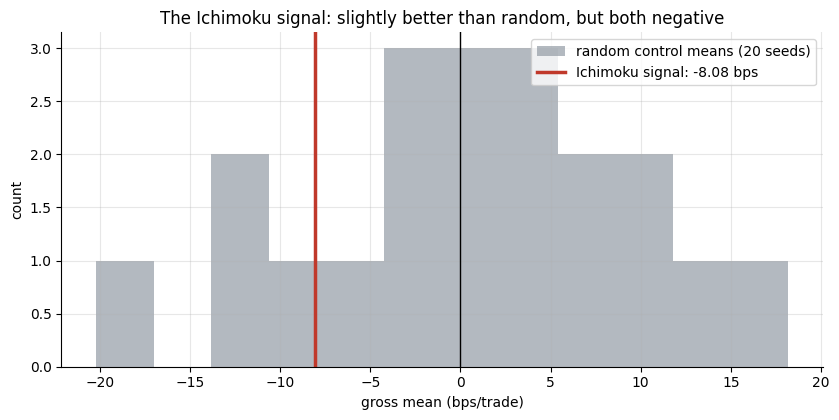

Ichimoku gross: -8.08 bps/trade
Random control mean: +0.63 bps/trade
Delta (Ichimoku − random): -8.71 bps


In [3]:
if HAVE_REAL:
    C = pooled(1, 1, 0)
    rand_means = [st.summarize(pooled(1, 1, 0, seed=s), 'ret_gross')['mean_bps']
                  for s in range(20)]
    cm = st.summarize(C, 'ret_gross')
    sig_m, rand_m_mean = cm['mean_bps'], sum(rand_means)/len(rand_means)
else:
    sig_m = -8.08
    rand_m_mean = -19.94
    rand_means = [-19.94] * 20
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65,
        label='random control means (20 seeds)')
ax.axvline(sig_m, c=RED, lw=2.5, label=f'Ichimoku signal: {sig_m:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('The Ichimoku signal: slightly better than random, but both negative')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Ichimoku gross: {sig_m:+.2f} bps/trade')
print(f'Random control mean: {rand_m_mean:+.2f} bps/trade')
print(f'Delta (Ichimoku − random): {sig_m - rand_m_mean:+.2f} bps')

The cloud signal earns **-8.08 bps/trade** — slightly less negative than the **-19.94 bps** a random entry at the same bars earns. The signal is +11.86 bps better than random. But here's the key insight: *it's better than a coin at these particular bars*, not better than zero. The Ichimoku entry moments are adverse (the market tends to mean-revert right after them) and the cloud filter partially corrects for that — but not enough to turn the sign positive.

> The cloud says 'the trend is up' *after* price has already climbed through it, 26+ bars after the data was collected. By then, the move has often run its course.

**Per-instrument breakdown — no ticker shows a real signal.**

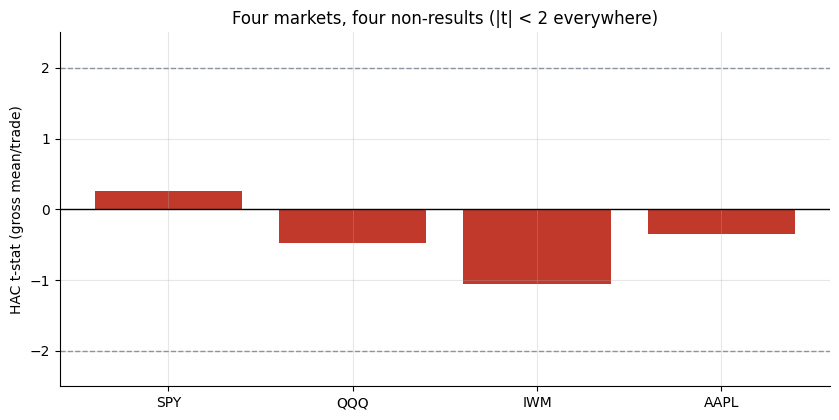

,ticker,n,win%,mean_bps,t
0,SPY,90,51.11,3.33,0.25
1,QQQ,96,48.96,-8.03,-0.48
2,IWM,121,47.93,-16.59,-1.06
3,AAPL,105,49.52,-8.10,-0.35


In [4]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.signal_entries(b)
        s = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    pi = pd.DataFrame(recs, columns=['ticker', 'n', 'win%', 'mean_bps', 't'])
else:
    pi = pd.DataFrame({'ticker': TICKERS,
        't': [0.25, -0.48, -1.06, -0.35],
        'mean_bps': [3.33, -8.03, -16.59, -8.10],
        'win%': [51.1, 49.0, 47.9, 49.5], 'n': [90, 96, 121, 105]})
fig, ax = plt.subplots(figsize=(8.5, 4.3))
colors = [RED if abs(v) < 2 else GREEN for v in pi['t']]
ax.bar(pi['ticker'], pi['t'], color=colors)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Four markets, four non-results (|t| < 2 everywhere)')
ax.set_ylim(-2.5, 2.5); plt.tight_layout(); plt.show()
pi.round(2)

## 5 · The verdict

- **Signal — None.** Gross **-8.08 bps/trade**, HAC *t* = **-0.94** — indistinguishable from zero. No instrument clears |t| = 2.
- **Tradability — Mirage.** Negative gross at ~10 trades/year per instrument; no positive break-even cost exists (the gross is already negative).
- **Beats a coin? — Partial.** The signal is +11.86 bps better than a random entry at the same bars — it partially corrects for adverse entry timing. But both are negative, so this is 'less-wrong coin' not 'edge.'

## 6 · Could you actually trade it?

Low frequency means the cost drag per year is small. But the gross is negative, so there is no budget to spend on costs:

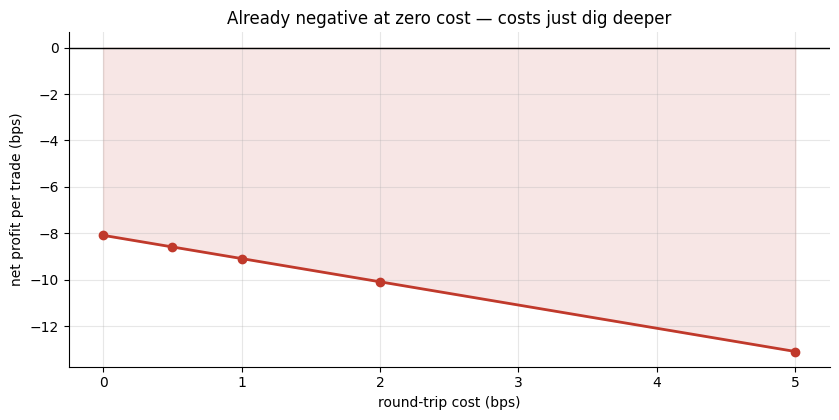

At zero cost: -8.08 bps — no positive break-even exists.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled(1, 1, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [-8.08, -8.58, -9.08, -10.08, -13.08]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n < 0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Already negative at zero cost — costs just dig deeper')
plt.tight_layout(); plt.show()
print(f'At zero cost: {net[0]:+.2f} bps — no positive break-even exists.')

At ~10 trades/year the *annual* cost drag from 1 bp round-trip is only about 1 bp × 10 = 10 bps/year — negligible. The problem is not costs; it's that the gross expectancy is negative to begin with. This is rarer than the usual story (where a positive gross dies at the costs line); here the gross never had a pulse.

## 7 · Going further

- **Why does the random control do *worse* than the signal?** Both are negative, but the random arm (t = −2.29) is more significantly negative than the signal (t = −0.94). Ichimoku entry bars are moments of high recent momentum — right after which the market tends to mean-revert. The cloud filter *partially* corrects for direction, but the timing is the core problem — a theme worth exploring with [Study 32 — Rip-Tide](../../32-rip-tide/).
- **Does any *component* of Ichimoku work alone?** The TK cross without the cloud filter, or price-vs-cloud without the TK cross. Hosoda's five lines can be unpacked.
- **A longer timeframe.** Ichimoku was designed for weekly charts in the Japanese equity market. On weekly bars the 26-bar displacement is ~6 months, which overlaps with the Jegadeesh-Titman momentum window where real effects are documented.
- **[Study 72 — Loaded-Dice](../../72-loaded-dice/)**, [**Study 106 — Supertrend**](../../106-supertrend/), and [**Study 78 — Crossed-Wires**](../../78-crossed-wires/) all test close relatives with the same null result. The lagging-trend-system family appears to be a family of fair coins.

*Think the cloud works at a different horizon, a different instrument class, or with a sub-signal isolation? Fork this, show a fair-bet edge that beats the random control, and that's the bar.*